# Libraries

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# Load CSV

In [3]:
df=pd.read_csv("customer_churn_dataset.csv")
df = df.copy()
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,Age,Income,Purchases,MonthlyCharges,TotalCharges,Churn,Notes
0,CUST-1383,Male,0,Yes,No,63,Yes,No,Month-to-month,No,Electronic check,53.0,59980.68,24.0,32.18,2093.74,No,NaN
1,CUST-1775,Male,0,No,No,56,Yes,Fiber optic,One year,Yes,Credit card,41.0,67088.04,21.0,25.59,1475.21,Yes,NaN
2,CUST-1791,Female,0,No,No,5,Yes,Fiber optic,Month-to-month,No,Bank transfer,64.0,64351.26,14.0,22.33,NaN,Yes,NaN
3,CUST-1131,Male,1,Yes,Yes,26,No,Fiber optic,Month-to-month,Yes,Electronic check,40.0,55714.34,19.0,59.13,1599.35,No,NaN
4,CUST-1464,Female,0,No,No,47,Yes,Fiber optic,Month-to-month,No,Bank transfer,NaN,58060.85,12.0,102.29,4797.28,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,CUST-1713,Female,0,No,No,2,Yes,No,Month-to-month,No,Bank transfer,33.0,18039.08,2.0,116.96,258.61,No,NaN
1016,CUST-1168,Male,0,No,No,50,Yes,DSL,Month-to-month,No,Bank transfer,24.0,53334.10,15.0,42.44,2075.21,No,NaN
1017,CUST-1185,Male,0,No,No,36,Yes,Fiber optic,Two year,Yes,Credit card,54.0,51952.12,19.0,81.49,2901.01,No,NaN
1018,CUST-1035,Male,1,Yes,No,53,Yes,Fiber optic,Month-to-month,No,Credit card,65.0,67612.49,29.0,23.15,1216.65,No,NaN


# Data understanding & cleaning 

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,Age,Income,Purchases,MonthlyCharges,TotalCharges,Churn,Notes
0,CUST-1383,Male,0,Yes,No,63,Yes,No,Month-to-month,No,Electronic check,53.0,59980.68,24.0,32.18,2093.74,No,NaN
1,CUST-1775,Male,0,No,No,56,Yes,Fiber optic,One year,Yes,Credit card,41.0,67088.04,21.0,25.59,1475.21,Yes,NaN
2,CUST-1791,Female,0,No,No,5,Yes,Fiber optic,Month-to-month,No,Bank transfer,64.0,64351.26,14.0,22.33,NaN,Yes,NaN
3,CUST-1131,Male,1,Yes,Yes,26,No,Fiber optic,Month-to-month,Yes,Electronic check,40.0,55714.34,19.0,59.13,1599.35,No,NaN
4,CUST-1464,Female,0,No,No,47,Yes,Fiber optic,Month-to-month,No,Bank transfer,NaN,58060.85,12.0,102.29,4797.28,No,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1020 non-null   object 
 1   gender            1020 non-null   object 
 2   SeniorCitizen     1020 non-null   int64  
 3   Partner           1020 non-null   object 
 4   Dependents        999 non-null    object 
 5   tenure            1020 non-null   int64  
 6   PhoneService      1020 non-null   object 
 7   InternetService   1000 non-null   object 
 8   Contract          1020 non-null   object 
 9   PaperlessBilling  1020 non-null   object 
 10  PaymentMethod     1020 non-null   object 
 11  Age               989 non-null    object 
 12  Income            970 non-null    float64
 13  Purchases         1020 non-null   float64
 14  MonthlyCharges    1020 non-null   float64
 15  TotalCharges      980 non-null    float64
 16  Churn             1020 non-null   object 


In [6]:
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents            21
tenure                 0
PhoneService           0
InternetService       20
Contract               0
PaperlessBilling       0
PaymentMethod          0
Age                   31
Income                50
Purchases              0
MonthlyCharges         0
TotalCharges          40
Churn                  0
Notes               1020
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(20)

In [8]:
#droping duplcate's
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df["Age"]

0       53.0
1       41.0
2       64.0
3       40.0
4        NaN
        ... 
1014    39.0
1015    33.0
1016    24.0
1017    54.0
1018    65.0
Name: Age, Length: 1000, dtype: object

In [10]:
#fixing age column
df["Age"].unique()

array(['53.0', '41.0', '64.0', '40.0', nan, '63.0', '49.0', '36.0',
       '42.0', '27.0', '20.0', '24.0', '45.0', '74.0', '43.0', '70.0',
       '19.0', '60.0', '23.0', '67.0', '46.0', '29.0', '68.0', '28.0',
       '35.0', '25.0', '65 yrs', '57.0', '62.0', '30.0', '50.0', '21.0',
       '47.0', '69.0', '34.0', '51.0', '56.0', '72.0', '37.0', '58.0',
       '33.0', '61.0', '32.0', '22.0', '55.0', '68 yrs', '73.0', '71.0',
       '44.0', '65.0', '18.0', '38.0', '52.0', '41 yrs', '59.0', '26.0',
       '46 yrs', '48.0', '66.0', '54.0', '59 yrs', '31.0', '39.0',
       '55 yrs', '57 yrs', '36 yrs', '30 yrs', '32 yrs', '43 yrs',
       '49 yrs', '52 yrs', '70 yrs'], dtype=object)

In [11]:
df["Age"]=df["Age"].astype(str).str.extract(r"(\d+)").astype(float)

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\234198158.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age"]=df["Age"].astype(str).str.extract(r"(\d+)").astype(float)


In [12]:
df["Age"]=df["Age"].fillna(df["Age"].median())

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\1392973377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age"]=df["Age"].fillna(df["Age"].median())


In [13]:
df["Age"].isnull().sum()

np.int64(0)

In [14]:
df["Age"]=df["Age"].astype(int)

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\2332842721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age"]=df["Age"].astype(int)


In [15]:
df["Age"].unique()

array([53, 41, 64, 40, 46, 63, 49, 36, 42, 27, 20, 24, 45, 74, 43, 70, 19,
       60, 23, 67, 29, 68, 28, 35, 25, 65, 57, 62, 30, 50, 21, 47, 69, 34,
       51, 56, 72, 37, 58, 33, 61, 32, 22, 55, 73, 71, 44, 18, 38, 52, 59,
       26, 48, 66, 54, 31, 39])

In [16]:
#fixing Dependents column
df["Dependents"].unique()
df["Dependents"].isnull().sum()

np.int64(20)

In [17]:
df["Dependents"]=df["Dependents"].fillna(df["Dependents"].mode()[0])

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\1629124507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Dependents"]=df["Dependents"].fillna(df["Dependents"].mode()[0])


In [18]:
df["Dependents"].isnull().sum()

np.int64(0)

In [19]:
# fixing InternetService column
df["InternetService"].unique()
df["InternetService"].isnull().sum()

np.int64(20)

In [20]:
df["InternetService"]=df["InternetService"].fillna(df["InternetService"].mode()[0])

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\1577332447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InternetService"]=df["InternetService"].fillna(df["InternetService"].mode()[0])


In [21]:
df["InternetService"].isnull().sum()

np.int64(0)

In [22]:
#fixing Income col
df["Income"].dtype

dtype('float64')

In [23]:
df["Income"].unique()

array([ 59980.68,  67088.04,  64351.26,  55714.34,  58060.85,  72782.38,
        79531.38,  32034.24,  71897.64,  36508.32,  49555.18,  90462.48,
        33867.24,  15893.61,  59376.51,  29874.52,  25906.88,  75598.21,
        53940.73,  45351.67,  48830.35,  64108.63,  54568.14,  65704.16,
             nan, 102066.38,  31225.71,  23281.02,  63266.2 ,  52819.32,
        45400.58,  56828.54,  50564.43,  51512.55,  51625.84,  42884.34,
        24679.69,  69182.13,  51300.98,  41436.7 ,  95513.95,  82377.73,
        84827.84,  68070.9 ,  51252.48,  45994.98,  18342.24,  47670.6 ,
        50206.18,  37228.41,  46027.1 ,  43149.28,  72407.18,  44225.43,
        64270.67,  26284.16,  51100.27,  42192.8 ,  34227.28,  40784.06,
        68632.66,  60778.48,  46907.28,  56004.26,  81951.33,  76316.55,
        64788.93,  46680.57,  63583.53,  58187.35,  88738.78,  26909.89,
        38295.66,  47089.57,  80151.29,  15000.  ,  62860.87,  43000.97,
        46952.26,  38350.24,  37056.56,  53130.22, 

In [24]:
df["Income"].isnull().sum()

np.int64(50)

<Axes: ylabel='Income'>

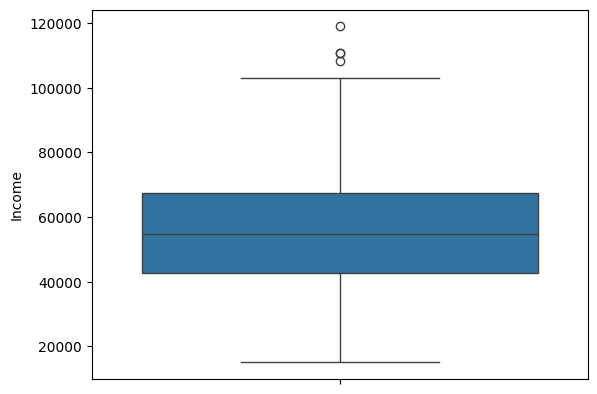

In [25]:
sns.boxplot(df["Income"])

In [26]:
df["Income"]=df["Income"].fillna(df["Income"].median())

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\1334420712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Income"]=df["Income"].fillna(df["Income"].median())


In [27]:
df["Income"].isnull().sum()

np.int64(0)

In [28]:
#fixing totalcharges column
df["TotalCharges"].unique()

array([2.09374e+03, 1.47521e+03,         nan, 1.59935e+03, 4.79728e+03,
       1.60926e+03, 6.32895e+03, 3.39886e+03, 2.91644e+03, 5.32280e+02,
       2.45442e+03, 4.05537e+03, 1.30681e+03, 1.35133e+03, 7.90600e+01,
       2.54689e+03, 1.80935e+03, 3.34060e+02, 9.77310e+02, 1.40680e+02,
       5.98269e+03, 1.85132e+03, 6.78238e+03, 8.79370e+02, 4.31117e+03,
       5.84788e+03, 9.74100e+02, 3.22738e+03, 5.63588e+03, 1.48257e+03,
       1.35296e+03, 9.70600e+02, 7.29540e+02, 5.51041e+03, 5.14303e+03,
       7.77360e+02, 5.62132e+03, 5.20530e+02, 2.35995e+03, 3.81137e+03,
       1.26685e+03, 1.62255e+03, 6.64830e+02, 1.39901e+03, 9.13120e+02,
       2.74352e+03, 3.60920e+02, 3.36841e+03, 1.44009e+03, 1.94175e+03,
       1.12150e+02, 7.53058e+03, 1.36284e+03, 9.60730e+02, 2.56616e+03,
       2.72259e+03, 4.58363e+03, 1.05680e+02, 1.76000e+01, 5.74230e+02,
       2.36990e+02, 7.01778e+03, 1.04006e+03, 5.44860e+02, 3.92155e+03,
       3.23610e+03, 2.20334e+03, 2.35542e+03, 4.02970e+03, 1.830

In [29]:
df["TotalCharges"].dtype

dtype('float64')

In [30]:
r=df["TotalCharges"].max()-df["TotalCharges"].min()
print(r)

8662.76


In [31]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\1536661067.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())


In [32]:
df["Income"].isnull().sum()

np.int64(0)

In [33]:
df["gender"]=df["gender"].str.lower()
df["gender"].unique()

C:\Users\Subhash Bishnoi\AppData\Local\Temp\ipykernel_9364\544911783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gender"]=df["gender"].str.lower()


array(['male', 'female'], dtype=object)

In [34]:
#droping irrelevant column
df=df.drop(columns=["Notes"])

In [35]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
InternetService     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Age                 0
Income              0
Purchases           0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Univariate Analysis

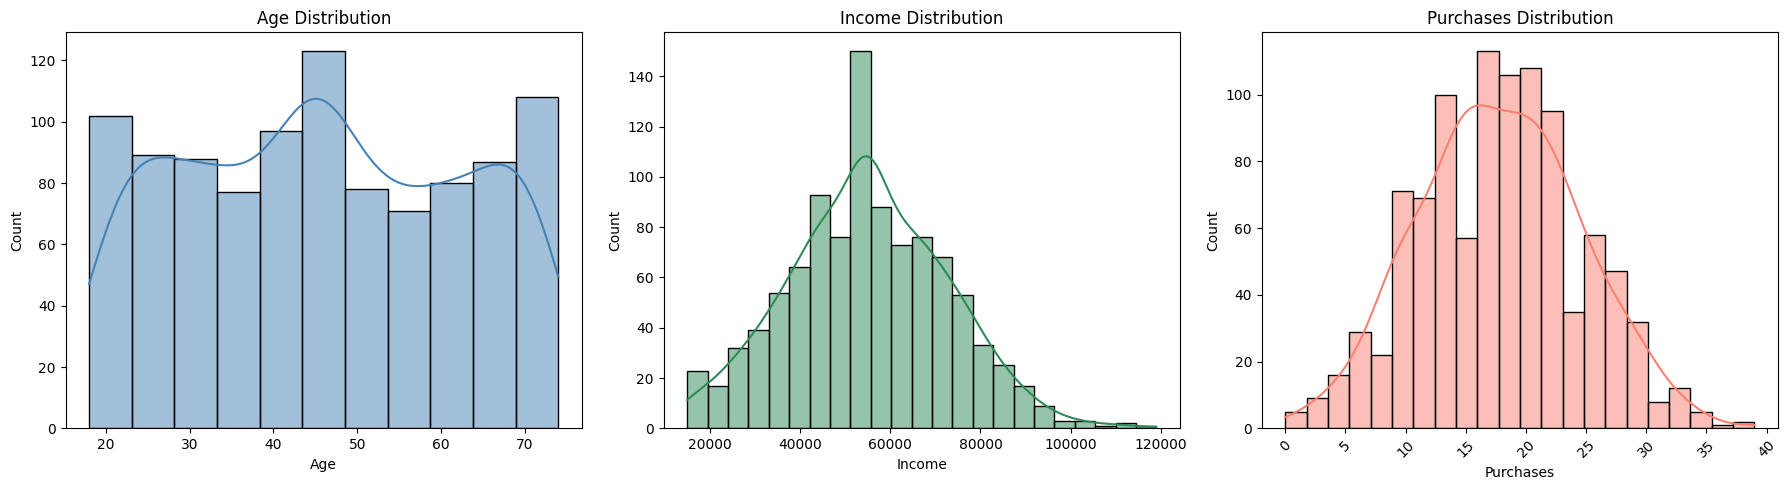

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Age"], kde=True, ax=axes[0], color="steelblue")
plt.xticks(rotation=45)
axes[0].set_title("Age Distribution")

sns.histplot(df["Income"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Income Distribution")

sns.histplot(df["Purchases"], kde=True, ax=axes[2], color="salmon")
axes[2].set_title("Purchases Distribution")

plt.tight_layout()
plt.show()

# Bivariate Analysis

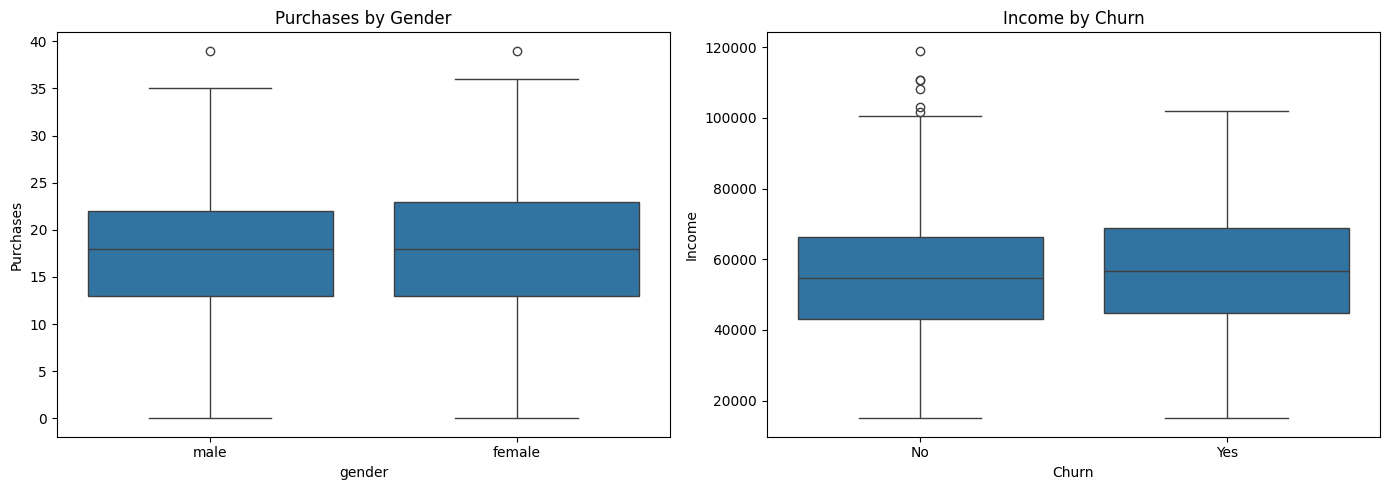

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender & Purchases
sns.boxplot(x="gender", y="Purchases", data=df, ax=axes[0])
axes[0].set_title("Purchases by Gender")

# Income & Churn
sns.boxplot(x="Churn", y="Income", data=df, ax=axes[1])
axes[1].set_title("Income by Churn")

plt.tight_layout()
plt.show()

# Multivariate Analysis

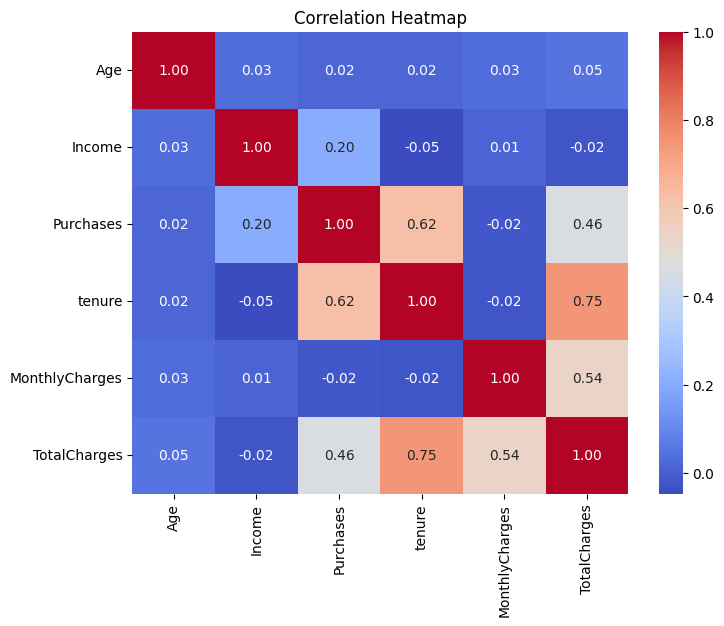

In [38]:
# Correlation heatmap of numeric columns
numeric_cols = ["Age", "Income", "Purchases", "tenure", "MonthlyCharges", "TotalCharges"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()